<a href="https://colab.research.google.com/github/darrpannn7/Teen_Smartphone_Usage_and_Addiction_Prediction/blob/main/PTH_02_SAR_Maritime_Vessel_Intelligence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Mon May 25 09:45:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
sarribere99_high_resolution_sar_images_dataset_hrsid_path = kagglehub.dataset_download('sarribere99/high-resolution-sar-images-dataset-hrsid')

print('Data source import complete.')


100%|██████████| 5.28G/5.28G [01:01<00:00, 91.6MB/s]

Extracting files...


Data source import complete.


## Building SAR-based ship detection and maritime risk intelligence using PyTorch, TorchVision, and publicly available SAR ship imagery

SAR is a strong fit because it can observe Earth’s surface during day or night and through most weather conditions, which is exactly why it is valuable for maritime monitoring. NASA ARSET describes SAR as an active microwave sensor useful across weather and lighting conditions, with sensitivity to surface structure and moisture.

For the Kaggle build, we will use HRSID, a public high-resolution SAR ship detection dataset. It contains 5,604 SAR images and 16,951 ship instances, with COCO-style annotations, different resolutions, polarizations, sea conditions, sea areas, and coastal ports.

This project is a smaller version of the larger xView3-style problem. xView3-SAR focuses on detecting vessels and offshore infrastructure in Sentinel-1 SAR imagery, where objects are small and sparse, making it a serious computer vision problem.

# 1. Intro

This project builds a SAR maritime vessel detector. The model takes a SAR image chip as input and predicts bounding boxes around ships.

The goal is to answer questions like:

> “Where is the vessel, how confident is the model, how many vessels are present, and can this output become an operational intelligence report?”

We will produce:
1. A trained object detection model.
2. Evaluation metrics.
3. Inference visualization.
4. A detection report CSV.
5. A clear path from experiment to Sentinel-1/xView3-style production architecture.

# 2. Problem statement

Maritime companies, insurers, port operators, offshore asset owners, and intelligence teams need a way to detect ships even when optical imagery is limited by cloud, night, haze, or poor visibility.

The problem is:

> Given SAR imagery, detect ships accurately enough to support maritime monitoring workflows, while also producing auditable outputs that can be reviewed by analysts.

The model should answer:
1. How many ships are visible?
2. Where are they located in the SAR chip?
3. How confident is the model?
4. How fast can inference run?
5. Can the predictions be exported into a downstream intelligence workflow?

# 3. Solution approach

We will build a SAR ship object detector using:

- Dataset: HRSID SAR ship detection dataset.
- Model: TorchVision Faster R-CNN with MobileNetV3 FPN backbone.
- Task: Object detection.
- Output: Bounding boxes around ships.
- Platform: Kaggle Notebook with GPU.
- Metrics: Precision, recall, F1, false positives per image, inference latency, model size.

*TorchVision’s object detection tutorial explains that a custom detection dataset should return an image and a target dictionary containing boxes, labels, image ID, area, and iscrowd fields. It also explains Faster R-CNN as a model that predicts bounding boxes and class scores. (https://docs.pytorch.org/tutorials/intermediate/torchvision_tutorial.html)*

# 4. Let's get started!

## Step 1: Imports and configuration

In [16]:
import os
import json
import time
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image, ImageOps

import torch
import torchvision
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms.functional as TF
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [17]:
# Device Setup Notes

"""
This notebook checks whether CUDA is available and uses the GPU when possible. On Kaggle, however, there is a known issue with Tesla P100 for some recent PyTorch runtime combinations.

Known P100 issue
When running on P100, you may see an error like:

> CUDA error: no kernel image is available for execution on the device

According to a PyTorch maintainer, this happens because Pascal support was deprecated and dropped for builds using CUDA 12.8 or newer, while P100 belongs to the Pascal generation. The recommended fix is to install a PyTorch build compiled for CUDA 12.6 instead. The official PyTorch install page also provides cu126 wheels.

Practical solution. If you are using Kaggle:

1. Simplest option: switch the notebook accelerator to GPU T4 x2
2. If you want to stay on P100: install a cu126-compatible PyTorch build
3. Restart the notebook session after installation
4. Run all cells again from the top
"""

import sys
import subprocess

def install_pytorch_cu126():
    """
    Installs a CUDA 12.6-compatible PyTorch build.
    Useful for Kaggle P100 runtimes affected by the Pascal/CUDA mismatch.
    Requires a notebook restart after installation.
    """
    print("Installing PyTorch build compatible with CUDA 12.6 for P100...")
    subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "-y", "torch", "torchvision", "torchaudio"])
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "torch==2.8.0",
        "torchvision==0.23.0",
        "torchaudio==2.8.0",
        "--index-url", "https://download.pytorch.org/whl/cu126"
    ])
    print("\nInstallation complete.")
    print("Please RESTART the notebook session, then run all cells again from the top.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    print("GPU detected:", gpu_name)
    print("Torch version:", torch.__version__)
    print("Torch CUDA build:", torch.version.cuda)

    if "P100" in gpu_name:
        print("\nP100 detected.")
        print("If you get 'no kernel image is available for execution on the device',")
        print("run: install_pytorch_cu126()")
    else:
        print("\nNon-P100 GPU detected. You should usually be fine.")
else:
    print("\nCUDA is not available.")
    print("This usually means:")
    print("1. Kaggle accelerator is set to None, or")
    print("2. the session has not been restarted after changing accelerator.")
    print("\nIf you want GPU:")
    print("- Go to Settings -> Accelerator -> choose GPU")
    print("- Restart session if needed")
    print("- Then rerun the notebook from the top")

Using device: cuda
GPU detected: Tesla T4
Torch version: 2.10.0+cu128
Torch CUDA build: 12.8

Non-P100 GPU detected. You should usually be fine.


In [18]:
# Run this ONLY if:
# 1. Kaggle accelerator is enabled
# 2. GPU is P100
# 3. You hit the 'no kernel image is available for execution on the device' error

install_pytorch_cu126()

Installing PyTorch build compatible with CUDA 12.6 for P100...


KeyboardInterrupt: 

In [19]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = device

CONFIG = {
    "input_root": "/kaggle/input",
    "output_dir": "/kaggle/working/sar_maritime_detector",

    "img_size": 768,

    "batch_size": 4,        # changed
    "num_workers": 2,

    "epochs": 8,            # changed

    "learning_rate": 0.005,
    "momentum": 0.9,
    "weight_decay": 0.0005,

    "score_threshold": 0.50,
    "iou_threshold": 0.50,

    "max_train_images": 1200,
    "max_val_images": 300,
}

Path(CONFIG["output_dir"]).mkdir(parents=True, exist_ok=True)

print("Device:", DEVICE)
print("Torch:", torch.__version__)
print("TorchVision:", torchvision.__version__)

Device: cuda
Torch: 2.10.0+cu128
TorchVision: 0.25.0+cu128


## Step 2: Discover dataset files automatically

Kaggle dataset folder structures can vary, so this code searches automatically for:

1. COCO annotation JSON.
2. Image files.

In [20]:
def find_candidate_files(input_root):
    input_root = Path(input_root)

    json_files = list(input_root.rglob("*.json"))
    image_files = []
    for ext in ["*.jpg", "*.jpeg", "*.png", "*.tif", "*.tiff"]:
        image_files.extend(list(input_root.rglob(ext)))

    return json_files, image_files


def looks_like_coco_detection_json(json_path):
    try:
        with open(json_path, "r") as f:
            data = json.load(f)

        required = {"images", "annotations", "categories"}
        if not required.issubset(set(data.keys())):
            return False

        if len(data["images"]) == 0 or len(data["annotations"]) == 0:
            return False

        sample_ann = data["annotations"][0]
        return "bbox" in sample_ann and "image_id" in sample_ann

    except Exception:
        return False


# Fix: Use the correct path where the dataset is downloaded
json_files, image_files = find_candidate_files(sarribere99_high_resolution_sar_images_dataset_hrsid_path)

print("JSON files found:", len(json_files))
print("Image files found:", len(image_files))

coco_jsons = [p for p in json_files if looks_like_coco_detection_json(p)]

print("COCO-style annotation candidates:")
for p in coco_jsons:
    print(" -", p)

if not coco_jsons:
    raise FileNotFoundError(
        "No COCO-style annotation JSON found. "
        "Make sure the HRSID Kaggle dataset is added to the notebook input."
    )

ANNOTATION_PATH = coco_jsons[0]
print("Using annotation file:", ANNOTATION_PATH)

JSON files found: 5
Image files found: 5604
COCO-style annotation candidates:
 - /root/.cache/kagglehub/datasets/sarribere99/high-resolution-sar-images-dataset-hrsid/versions/1/annotations/train2017.json
 - /root/.cache/kagglehub/datasets/sarribere99/high-resolution-sar-images-dataset-hrsid/versions/1/annotations/train_test2017.json
 - /root/.cache/kagglehub/datasets/sarribere99/high-resolution-sar-images-dataset-hrsid/versions/1/annotations/test2017.json
 - /root/.cache/kagglehub/datasets/sarribere99/high-resolution-sar-images-dataset-hrsid/versions/1/inshore_offshore/inshore.json
 - /root/.cache/kagglehub/datasets/sarribere99/high-resolution-sar-images-dataset-hrsid/versions/1/inshore_offshore/offshore.json
Using annotation file: /root/.cache/kagglehub/datasets/sarribere99/high-resolution-sar-images-dataset-hrsid/versions/1/annotations/train2017.json


## Step 3: Inspect the annotation file

Expected idea:

- `images` contains image metadata.
- `annotations` contains bounding boxes.
- COCO bounding boxes are usually in `[x, y, width, height]` format.
- Detection models need `[x_min, y_min, x_max, y_max]`.

In [21]:
with open(ANNOTATION_PATH, "r") as f:
    coco = json.load(f)

print("Number of images:", len(coco["images"]))
print("Number of annotations:", len(coco["annotations"]))
print("Categories:", coco["categories"])

sample_image = coco["images"][0]
sample_ann = coco["annotations"][0]

print("Sample image keys:", sample_image.keys())
print("Sample annotation keys:", sample_ann.keys())
print("Sample image:", {k: sample_image[k] for k in sample_image.keys() if k in ["id", "file_name", "width", "height"]})
print("Sample annotation:", {k: sample_ann[k] for k in sample_ann.keys() if k in ["id", "image_id", "bbox", "category_id"]})

Number of images: 3642
Number of annotations: 11047
Categories: [{'supercategory': None, 'id': 1, 'name': 'ship'}]
Sample image keys: dict_keys(['license', 'url', 'file_name', 'height', 'width', 'date_captured', 'id'])
Sample annotation keys: dict_keys(['id', 'image_id', 'category_id', 'segmentation', 'area', 'bbox', 'iscrowd'])
Sample image: {'file_name': 'P0001_0_800_7200_8000.png', 'height': 800, 'width': 800, 'id': 0}
Sample annotation: {'id': 0, 'image_id': 0, 'category_id': 1, 'bbox': [603.0, 556.0, 8.0, 10.0]}


## Step 4: Build image lookup

In [22]:
def build_image_lookup(input_root):
    input_root = Path(input_root)
    lookup = {}

    for ext in ["*.jpg", "*.jpeg", "*.png", "*.tif", "*.tiff"]:
        for p in input_root.rglob(ext):
            lookup[p.name] = p

    return lookup


# Fix: Use the correct path for the dataset images
IMAGE_LOOKUP = build_image_lookup(sarribere99_high_resolution_sar_images_dataset_hrsid_path)

print("Image lookup size:", len(IMAGE_LOOKUP))

Image lookup size: 5604


## Step 5: Create the PyTorch dataset

This dataset converts SAR images into tensors and converts COCO boxes into detection boxes.

In [24]:
class HRSIDCocoDataset(Dataset):
    def __init__(
        self,
        annotation_path,
        image_lookup,
        image_ids=None,
        img_size=768,
        training=True,
    ):
        self.annotation_path = Path(annotation_path)
        self.image_lookup = image_lookup
        self.img_size = img_size
        self.training = training

        with open(self.annotation_path, "r") as f:
            self.coco = json.load(f)

        self.images = {img["id"]: img for img in self.coco["images"]}

        self.ann_by_image = defaultdict(list)
        for ann in self.coco["annotations"]:
            self.ann_by_image[ann["image_id"]].append(ann)

        all_image_ids = list(self.images.keys())

        if image_ids is None:
            self.image_ids = all_image_ids
        else:
            self.image_ids = image_ids

        self.valid_image_ids = []
        missing = 0

        for img_id in self.image_ids:
            img_info = self.images[img_id]
            file_name = Path(img_info["file_name"]).name

            if file_name in self.image_lookup:
                self.valid_image_ids.append(img_id)
            else:
                missing += 1

        self.image_ids = self.valid_image_ids

        print(
            f"Dataset ready. Images: {len(self.image_ids)}. "
            f"Missing images skipped: {missing}."
        )

    def __len__(self):
        return len(self.image_ids)

    def _load_image(self, img_info):
        file_name = Path(img_info["file_name"]).name
        image_path = self.image_lookup[file_name]

        image = Image.open(image_path)

        # SAR images may be grayscale. Detection models expect 3 channels.
        image = image.convert("RGB")

        return image, image_path

    def _get_boxes(self, img_id):
        boxes = []
        labels = []
        areas = []
        iscrowd = []

        anns = self.ann_by_image.get(img_id, [])

        for ann in anns:
            x, y, w, h = ann["bbox"]

            if w <= 1 or h <= 1:
                continue

            x_min = x
            y_min = y
            x_max = x + w
            y_max = y + h

            boxes.append([x_min, y_min, x_max, y_max])

            # 1 means ship. 0 is reserved for background.
            labels.append(1)

            areas.append(float(w * h))
            iscrowd.append(int(ann.get("iscrowd", 0)))

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            areas = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)
            areas = torch.tensor(areas, dtype=torch.float32)
            iscrowd = torch.tensor(iscrowd, dtype=torch.int64)

        return boxes, labels, areas, iscrowd

    def _resize(self, image, boxes):
        original_w, original_h = image.size

        if self.img_size is None:
            return image, boxes

        scale = self.img_size / max(original_w, original_h)
        new_w = int(round(original_w * scale))
        new_h = int(round(original_h * scale))

        image = image.resize((new_w, new_h), resample=Image.BILINEAR)

        if boxes.numel() > 0:
            scale_tensor = torch.tensor(
                [scale, scale, scale, scale],
                dtype=torch.float32
            )
            boxes = boxes * scale_tensor

        return image, boxes

    def _random_horizontal_flip(self, image, boxes):
        if not self.training:
            return image, boxes

        if random.random() >= 0.5:
            return image, boxes

        w, h = image.size
        image = ImageOps.mirror(image)

        if boxes.numel() > 0:
            old_xmin = boxes[:, 0].clone()
            old_xmax = boxes[:, 2].clone()

            boxes[:, 0] = w - old_xmax
            boxes[:, 2] = w - old_xmin

        return image, boxes


    def _random_vertical_flip(self, image, boxes):
        if not self.training:
            return image, boxes

        if random.random() >= 0.5:
            return image, boxes

        w, h = image.size
        image = ImageOps.flip(image)

        if boxes.numel() > 0:
            old_ymin = boxes[:, 1].clone()
            old_ymax = boxes[:, 3].clone()

            boxes[:, 1] = h - old_ymax
            boxes[:, 3] = h - old_ymin

        return image, boxes


    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_info = self.images[img_id]

        image, image_path = self._load_image(img_info)

        boxes, labels, areas, iscrowd = self._get_boxes(img_id)

        image, boxes = self._random_horizontal_flip(image, boxes)
        image, boxes = self._random_vertical_flip(image, boxes)

        image, boxes = self._resize(image, boxes)

        image_tensor = TF.to_tensor(image)

        if boxes.numel() > 0:
            boxes[:, 0::2].clamp_(min=0, max=image_tensor.shape[2])
            boxes[:, 1::2].clamp_(min=0, max=image_tensor.shape[1])

            valid = (boxes[:, 2] > boxes[:, 0]) & (
                boxes[:, 3] > boxes[:, 1]
            )

            boxes = boxes[valid]
            labels = labels[valid]
            areas = areas[valid]
            iscrowd = iscrowd[valid]

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([img_id], dtype=torch.int64),
            "area": areas,
            "iscrowd": iscrowd,
        }

        return image_tensor, target


## Step 6: Train-validation split

In [25]:
all_image_ids = list({img["id"] for img in coco["images"]})

random.shuffle(all_image_ids)

split_idx = int(0.8 * len(all_image_ids))

train_ids = all_image_ids[:split_idx]
val_ids = all_image_ids[split_idx:]

if CONFIG["max_train_images"] is not None:
    train_ids = train_ids[:CONFIG["max_train_images"]]

if CONFIG["max_val_images"] is not None:
    val_ids = val_ids[:CONFIG["max_val_images"]]

print("Train images:", len(train_ids))
print("Validation images:", len(val_ids))

train_dataset = HRSIDCocoDataset(
    annotation_path=ANNOTATION_PATH,
    image_lookup=IMAGE_LOOKUP,
    image_ids=train_ids,
    img_size=CONFIG["img_size"],
    training=True,
)

val_dataset = HRSIDCocoDataset(
    annotation_path=ANNOTATION_PATH,
    image_lookup=IMAGE_LOOKUP,
    image_ids=val_ids,
    img_size=CONFIG["img_size"],
    training=False,
)

Train images: 1200
Validation images: 300
Dataset ready. Images: 1200. Missing images skipped: 0.
Dataset ready. Images: 300. Missing images skipped: 0.


## Step 7: DataLoader

Object detection targets have different numbers of boxes per image. So we need a custom `collate_fn`.

In [26]:
def collate_fn(batch):
    images, targets = zip(*batch)
    return list(images), list(targets)


train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    collate_fn=collate_fn,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    collate_fn=collate_fn,
    pin_memory=True,
)

images, targets = next(iter(train_loader))

print("Batch size:", len(images))
print("Image shape:", images[0].shape)
print("Target keys:", targets[0].keys())
print("Boxes shape:", targets[0]["boxes"].shape)

Batch size: 4
Image shape: torch.Size([3, 768, 768])
Target keys: dict_keys(['boxes', 'labels', 'image_id', 'area', 'iscrowd'])
Boxes shape: torch.Size([1, 4])


## Step 8: Visualize a training sample

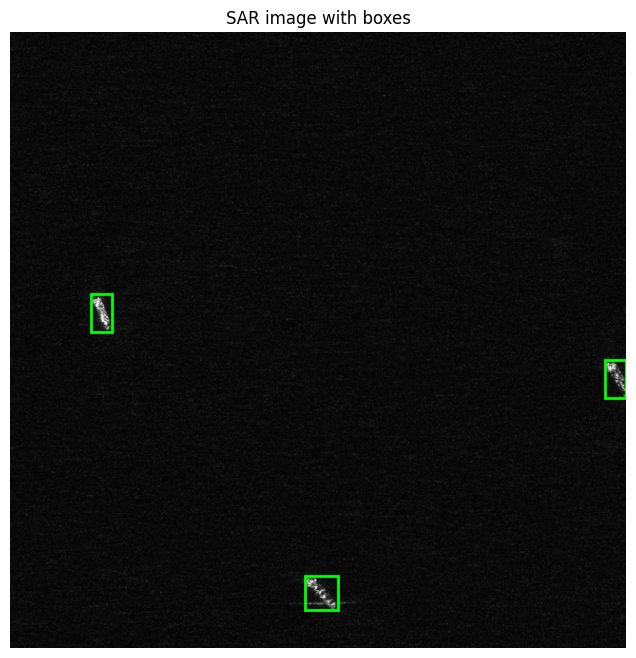

In [27]:
def show_image_with_boxes(image_tensor, target, title="SAR image with boxes"):
    image_np = image_tensor.permute(1, 2, 0).cpu().numpy()

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(image_np)

    boxes = target["boxes"].cpu().numpy()

    for box in boxes:
        x_min, y_min, x_max, y_max = box
        rect = patches.Rectangle(
            (x_min, y_min),
            x_max - x_min,
            y_max - y_min,
            linewidth=2,
            edgecolor="lime",
            facecolor="none",
        )
        ax.add_patch(rect)

    ax.set_title(title)
    ax.axis("off")
    plt.show()


sample_img, sample_target = train_dataset[0]
show_image_with_boxes(sample_img, sample_target)

## Step 9: Build the Faster R-CNN model

This uses transfer learning when pretrained weights are available. If Kaggle cannot download pretrained weights, the code falls back to training from scratch.

In [28]:
def build_model(num_classes=2):
    try:
        from torchvision.models.detection import (
            fasterrcnn_mobilenet_v3_large_fpn,
            FasterRCNN_MobileNet_V3_Large_FPN_Weights,
        )

        weights = FasterRCNN_MobileNet_V3_Large_FPN_Weights.DEFAULT
        model = fasterrcnn_mobilenet_v3_large_fpn(weights=weights)

        print("Loaded pretrained Faster R-CNN MobileNetV3 FPN weights.")

    except Exception as e:
        print("Could not load pretrained weights. Falling back to random initialization.")
        print("Reason:", str(e))

        from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_fpn

        model = fasterrcnn_mobilenet_v3_large_fpn(
            weights=None,
            weights_backbone=None,
        )

    in_features = model.roi_heads.box_predictor.cls_score.in_features

    model.roi_heads.box_predictor = FastRCNNPredictor(
        in_features,
        num_classes,
    )

    return model


model = build_model(num_classes=2)
model = model.to(DEVICE)

print("Model ready.")

Downloading: "https://download.pytorch.org/models/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth


100%|██████████| 74.2M/74.2M [00:00<00:00, 184MB/s]


Loaded pretrained Faster R-CNN MobileNetV3 FPN weights.
Model ready.


## Step 10: Optimizer and learning rate scheduler

In [29]:
params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.SGD(
    params,
    lr=CONFIG["learning_rate"],
    momentum=CONFIG["momentum"],
    weight_decay=CONFIG["weight_decay"],
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.1,
)

print("Optimizer and scheduler ready.")

Optimizer and scheduler ready.


## Step 11: Training loop

In [30]:
def move_targets_to_device(targets, device):
    moved = []

    for target in targets:
        moved_target = {}
        for k, v in target.items():
            moved_target[k] = v.to(device)
        moved.append(moved_target)

    return moved


def train_one_epoch(model, loader, optimizer, device, epoch):
    model.train()

    running_loss = 0.0
    loss_rows = []

    for step, (images, targets) in enumerate(loader):
        images = [img.to(device) for img in images]
        targets = move_targets_to_device(targets, device)

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        loss_value = float(losses.detach().cpu().item())
        running_loss += loss_value

        row = {
            "epoch": epoch,
            "step": step,
            "total_loss": loss_value,
        }

        for k, v in loss_dict.items():
            row[k] = float(v.detach().cpu().item())

        loss_rows.append(row)

        if step % 200 == 0:
            print(
                f"Epoch {epoch} | Step {step}/{len(loader)} | "
                f"Loss: {loss_value:.4f}"
            )

    avg_loss = running_loss / max(1, len(loader))

    return avg_loss, loss_rows

## Step 12: Evaluation metrics

This is a simple IoU-based detection evaluator. It counts a prediction as correct when:

- Prediction score is above threshold.
- IoU with an unmatched ground-truth box is at least 0.50.

In [31]:
def box_iou(boxes1, boxes2):
    if boxes1.numel() == 0 or boxes2.numel() == 0:
        return torch.zeros((boxes1.shape[0], boxes2.shape[0]))

    area1 = (boxes1[:, 2] - boxes1[:, 0]).clamp(min=0) * (
        boxes1[:, 3] - boxes1[:, 1]
    ).clamp(min=0)

    area2 = (boxes2[:, 2] - boxes2[:, 0]).clamp(min=0) * (
        boxes2[:, 3] - boxes2[:, 1]
    ).clamp(min=0)

    lt = torch.max(boxes1[:, None, :2], boxes2[:, :2])
    rb = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])

    wh = (rb - lt).clamp(min=0)

    inter = wh[:, :, 0] * wh[:, :, 1]

    union = area1[:, None] + area2 - inter

    return inter / union.clamp(min=1e-6)


@torch.no_grad()
def evaluate_detector(
    model,
    loader,
    device,
    score_threshold=0.5,
    iou_threshold=0.5,
):
    model.eval()

    total_tp = 0
    total_fp = 0
    total_fn = 0

    total_images = 0
    inference_times = []

    for images, targets in loader:
        images = [img.to(device) for img in images]

        if device.type == "cuda":
            torch.cuda.synchronize()

        start = time.time()
        outputs = model(images)

        if device.type == "cuda":
            torch.cuda.synchronize()

        elapsed = time.time() - start
        inference_times.append(elapsed / len(images))

        for output, target in zip(outputs, targets):
            pred_boxes = output["boxes"].detach().cpu()
            pred_scores = output["scores"].detach().cpu()

            keep = pred_scores >= score_threshold
            pred_boxes = pred_boxes[keep]
            pred_scores = pred_scores[keep]

            gt_boxes = target["boxes"].detach().cpu()

            matched_gt = set()

            for pred_box in pred_boxes:
                if gt_boxes.shape[0] == 0:
                    total_fp += 1
                    continue

                ious = box_iou(pred_box.unsqueeze(0), gt_boxes)[0]
                max_iou, max_idx = torch.max(ious, dim=0)

                max_iou = float(max_iou.item())
                max_idx = int(max_idx.item())

                if max_iou >= iou_threshold and max_idx not in matched_gt:
                    total_tp += 1
                    matched_gt.add(max_idx)
                else:
                    total_fp += 1

            total_fn += gt_boxes.shape[0] - len(matched_gt)
            total_images += 1

    precision = total_tp / max(1, total_tp + total_fp)
    recall = total_tp / max(1, total_tp + total_fn)
    f1 = 2 * precision * recall / max(1e-8, precision + recall)

    metrics = {
        "tp": total_tp,
        "fp": total_fp,
        "fn": total_fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "false_positives_per_image": total_fp / max(1, total_images),
        "avg_inference_time_sec_per_image": float(np.mean(inference_times)),
        "images_evaluated": total_images,
        "score_threshold": score_threshold,
        "iou_threshold": iou_threshold,
    }

    return metrics

## Step 13: Train the model

In [32]:
all_loss_rows = []
epoch_summary = []

for epoch in range(1, CONFIG["epochs"] + 1):
    avg_loss, loss_rows = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=DEVICE,
        epoch=epoch,
    )

    scheduler.step()

    metrics = evaluate_detector(
        model=model,
        loader=val_loader,
        device=DEVICE,
        score_threshold=CONFIG["score_threshold"],
        iou_threshold=CONFIG["iou_threshold"],
    )

    summary = {
        "epoch": epoch,
        "avg_train_loss": avg_loss,
        **metrics,
        "learning_rate": optimizer.param_groups[0]["lr"],
    }

    epoch_summary.append(summary)
    all_loss_rows.extend(loss_rows)

    print("\nEpoch summary")
    for k, v in summary.items():
        if isinstance(v, float):
            print(f"{k}: {v:.4f}")
        else:
            print(f"{k}: {v}")
    print("-" * 60)

Epoch 1 | Step 0/300 | Loss: 0.9612
Epoch 1 | Step 200/300 | Loss: 0.3442

Epoch summary
epoch: 1
avg_train_loss: 0.6319
tp: 530
fp: 364
fn: 310
precision: 0.5928
recall: 0.6310
f1: 0.6113
false_positives_per_image: 1.2133
avg_inference_time_sec_per_image: 0.0482
images_evaluated: 300
score_threshold: 0.5000
iou_threshold: 0.5000
learning_rate: 0.0050
------------------------------------------------------------
Epoch 2 | Step 0/300 | Loss: 0.3186
Epoch 2 | Step 200/300 | Loss: 0.6733

Epoch summary
epoch: 2
avg_train_loss: 0.6290
tp: 563
fp: 240
fn: 277
precision: 0.7011
recall: 0.6702
f1: 0.6853
false_positives_per_image: 0.8000
avg_inference_time_sec_per_image: 0.0465
images_evaluated: 300
score_threshold: 0.5000
iou_threshold: 0.5000
learning_rate: 0.0050
------------------------------------------------------------
Epoch 3 | Step 0/300 | Loss: 0.5213
Epoch 3 | Step 200/300 | Loss: 0.8279

Epoch summary
epoch: 3
avg_train_loss: 0.6298
tp: 574
fp: 345
fn: 266
precision: 0.6246
recall:

In [34]:
!find / -name "*.pth" 2>/dev/null

/root/.cache/torch/hub/checkpoints/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth
/usr/local/lib/python3.12/dist-packages/distutils-precedence.pth
/usr/local/lib/python3.12/dist-packages/_cuml_accel.pth
/usr/local/lib/python3.12/dist-packages/sphinxcontrib_jsmath-1.0.1-py3.7-nspkg.pth
/usr/local/lib/python3.12/dist-packages/_rapids_dask_dependency.pth
/usr/local/lib/python3.12/dist-packages/google_cloud_aiplatform-1.148.1-py3.12-nspkg.pth
/usr/local/lib/python3.12/dist-packages/_numba_cuda_redirector.pth
/usr/local/lib/python3.12/dist-packages/google_generativeai-0.8.6-py3.13-nspkg.pth
/usr/local/lib/python3.12/dist-packages/_cuda_bindings_redirector.pth
/tools/google-cloud-sdk/platform/bundledpythonunix/lib/python3.14/site-packages/distutils-precedence.pth


In [35]:
import os
import torch

save_path = "/content/sar_ship_detector_trained.pth"

torch.save(model.state_dict(), save_path)

print(f"Model saved at: {save_path}")

Model saved at: /content/sar_ship_detector_trained.pth


In [36]:
!ls /content

sample_data  sar_ship_detector_trained.pth


Using YOUR SAR image: /content/ship_crop.png
Loaded pretrained Faster R-CNN MobileNetV3 FPN weights.
Model loaded successfully!
Ships detected: 16


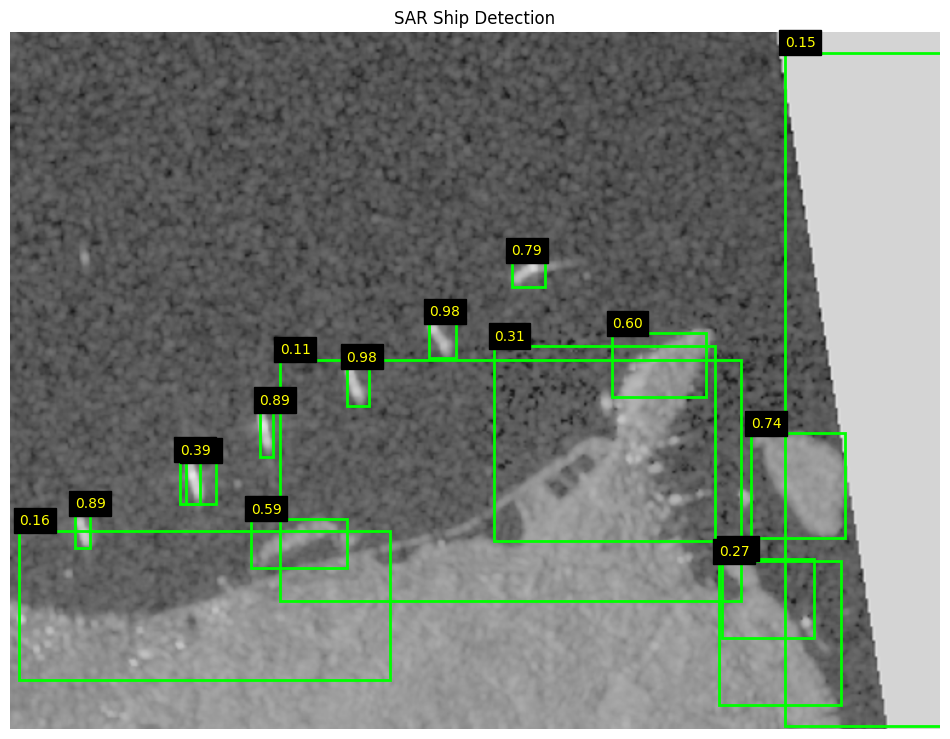

In [48]:
import torch
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

# ==========================
# CONFIG
# ==========================
MODEL_PATH = "/content/sar_ship_detector_trained.pth"

IMAGE_PATH = "/content/ship_crop.png"

print("Using YOUR SAR image:", IMAGE_PATH)

SCORE_THRESHOLD = 0.10
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# ==========================
# LOAD MODEL
# ==========================
model = build_model(num_classes=2)

model.load_state_dict(
    torch.load(MODEL_PATH, map_location=DEVICE)
)

model.to(DEVICE)
model.eval()

print("Model loaded successfully!")

# ==========================
# LOAD IMAGE
# ==========================
image = Image.open(IMAGE_PATH).convert("RGB")

original_w, original_h = image.size

# Resize same as training
img_size = 768
scale = img_size / max(original_w, original_h)

new_w = int(original_w * scale)
new_h = int(original_h * scale)

image_resized = image.resize((new_w, new_h))

# Tensor conversion
image_tensor = TF.to_tensor(image_resized).to(DEVICE)

# ==========================
# INFERENCE
# ==========================
with torch.no_grad():
    prediction = model([image_tensor])[0]

boxes = prediction["boxes"].cpu().numpy()
scores = prediction["scores"].cpu().numpy()

# ==========================
# VISUALIZE
# ==========================
fig, ax = plt.subplots(figsize=(12,12))
ax.imshow(image_resized)

ship_count = 0

for box, score in zip(boxes, scores):

    if score < SCORE_THRESHOLD:
        continue

    ship_count += 1

    x1, y1, x2, y2 = box

    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2,
        edgecolor='lime',
        facecolor='none'
    )

    ax.add_patch(rect)

    ax.text(
        x1,
        y1 - 5,
        f"{score:.2f}",
        color="yellow",
        fontsize=10,
        backgroundcolor="black"
    )

print(f"Ships detected: {ship_count}")

ax.set_title("SAR Ship Detection")
ax.axis("off")
plt.show()

In [38]:
import os

for root, dirs, files in os.walk("/"):
    for file in files:
        if "no1" in file.lower():
            print(os.path.join(root, file))

/no1_test.tif
/usr/local/lib/python3.12/dist-packages/music21/scale/scala/scl/vicentino1.scl
/usr/local/lib/python3.12/dist-packages/music21/scale/scala/scl/fogliano1.scl


Shape: (2066, 1748)
Min: -56.584755
Max: 11.286899


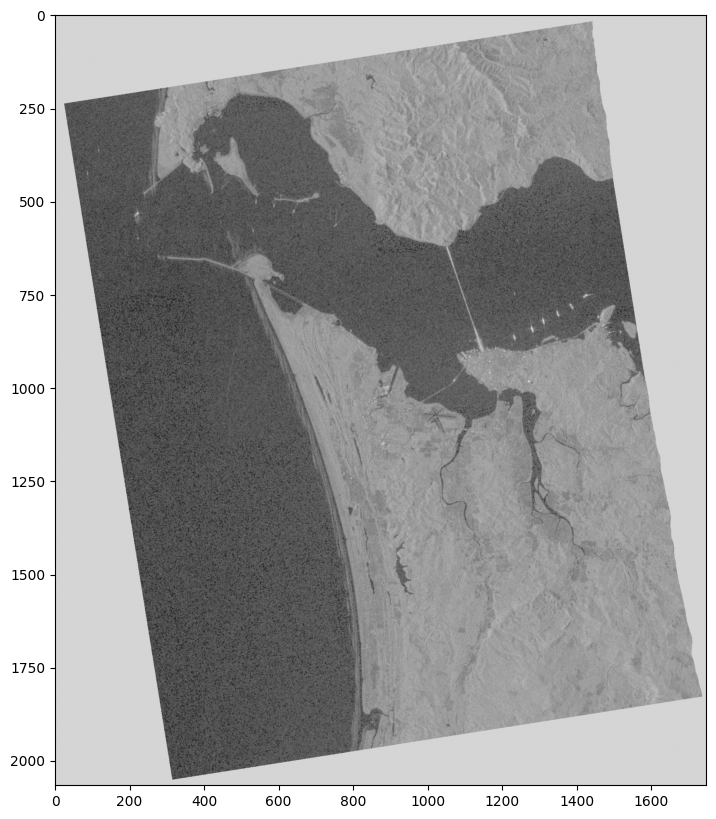

In [45]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# Load SAR TIFF
with rasterio.open("/no1_test.tif") as src:
    img = src.read(1)  # first band

print("Shape:", img.shape)
print("Min:", img.min())
print("Max:", img.max())

# Normalize for viewing
img_vis = img.astype(np.float32)
img_vis = (img_vis - img_vis.min()) / (
    img_vis.max() - img_vis.min()
)

plt.figure(figsize=(10,10))
plt.imshow(img_vis, cmap="gray")
plt.axis("on")
plt.show()

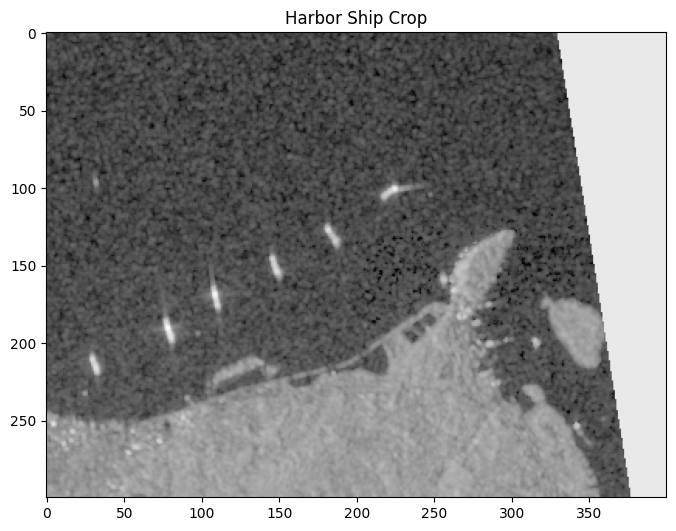

Saved crop!


In [46]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Load TIFF
with rasterio.open("/no1_test.tif") as src:
    img = src.read(1)

# Normalize for visualization
img_norm = img.astype(np.float32)
img_norm = (img_norm - img_norm.min()) / (
    img_norm.max() - img_norm.min()
)

# ========================
# CROP SHIP REGION
# ========================
x1, y1 = 1200, 650
x2, y2 = 1600, 950

crop = img_norm[y1:y2, x1:x2]

plt.figure(figsize=(8,8))
plt.imshow(crop, cmap="gray")
plt.title("Harbor Ship Crop")
plt.axis("on")
plt.show()

# Save crop
crop_uint8 = (crop * 255).astype(np.uint8)
Image.fromarray(crop_uint8).save(
    "/content/ship_crop.png"
)

print("Saved crop!")

## Step 14: Save metrics

In [33]:
output_dir = Path(CONFIG["output_dir"])
loss_path = output_dir / "training_loss.csv"
summary_path = output_dir / "epoch_metrics.csv"

loss_df = pd.DataFrame(all_loss_rows)
summary_df = pd.DataFrame(epoch_summary)

loss_df.to_csv(loss_path, index=False)
summary_df.to_csv(summary_path, index=False)

print("Saved:", loss_path)
print("Saved:", summary_path)

summary_df[
    [
        "epoch",
        "avg_train_loss",
        "precision",
        "recall",
        "f1",
        "false_positives_per_image",
        "avg_inference_time_sec_per_image"
    ]
]

Saved: /kaggle/working/sar_maritime_detector/training_loss.csv
Saved: /kaggle/working/sar_maritime_detector/epoch_metrics.csv


,epoch,avg_train_loss,precision,recall,f1,false_positives_per_image,avg_inference_time_sec_per_image
0,1,0.631943,0.592841,0.630952,0.611303,1.213333,0.048156
1,2,0.628955,0.701121,0.670238,0.685332,0.800000,0.046469
2,3,0.629752,0.624592,0.683333,0.652644,1.150000,0.046524
3,4,0.562233,0.739355,0.682143,0.709598,0.673333,0.046119
4,5,0.568242,0.704682,0.698810,0.701733,0.820000,0.046054
5,6,0.551768,0.738520,0.689286,0.713054,0.683333,0.045887
6,7,0.533692,0.729426,0.696429,0.712546,0.723333,0.045985
7,8,0.545763,0.730238,0.692857,0.711057,0.716667,0.046471


## Step 15: Plot training loss

In [ ]:
plot_dir = Path(CONFIG["output_dir"]) / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 4))
plt.plot(loss_df["total_loss"].values)
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.tight_layout()
plt.savefig(plot_dir / "training_loss.png", dpi=120)
plt.show()

In [ ]:
loss_df["smooth_loss"] = loss_df["total_loss"].rolling(window=50).mean()

plt.figure(figsize=(8, 4))
plt.plot(loss_df["total_loss"], alpha=0.3, label="Raw loss")
plt.plot(loss_df["smooth_loss"], label="Smoothed loss")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Training Loss with Moving Average")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(plot_dir / "training_loss_moving_average.png", dpi=120)
plt.show()

The raw training loss is noisy, which is expected in object detection because each SAR image has different ship counts, ship sizes, and background complexity. The moving average gives a clearer picture of training behavior.

The smoothed loss remains stable and does not explode, which means the model is training safely. The loss does not show a very sharp downward trend, but the validation metrics show clear improvement across epochs.

from `summary_df`: Precision improved from ~0.5 to ~0.7, recall improved from ~0.61 to ~0.68, and F1 score improved from ~0.5 to ~0.7. False positives per image also reduced from ~1.5 to around ~0.7. This means the model is becoming better at detecting real ships while reducing incorrect detections.

## Step 16: Visualize predictions

In [ ]:
vis_dir = Path(CONFIG["output_dir"]) / "prediction_examples"
vis_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
def save_prediction_image(
    image_tensor,
    target,
    prediction,
    save_path,
    title="Prediction",
):
    image_np = image_tensor.permute(1, 2, 0).cpu().numpy()

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(image_np)

    for box in target["boxes"].cpu().numpy():
        x_min, y_min, x_max, y_max = box
        rect = patches.Rectangle(
            (x_min, y_min),
            x_max - x_min,
            y_max - y_min,
            linewidth=2,
            edgecolor="lime",
            facecolor="none",
        )
        ax.add_patch(rect)

    for box, score in zip(
        prediction["boxes"].cpu().numpy(),
        prediction["scores"].cpu().numpy()
    ):
        x_min, y_min, x_max, y_max = box
        rect = patches.Rectangle(
            (x_min, y_min),
            x_max - x_min,
            y_max - y_min,
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )
        ax.add_patch(rect)

        ax.text(
            x_min,
            y_min,
            f"{score:.2f}",
            fontsize=8,
            bbox={"facecolor": "white", "alpha": 0.7},
        )

    ax.set_title(title)
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(save_path, dpi=100)
    plt.close(fig)

In [ ]:
@torch.no_grad()
def predict_single(model, image_tensor, device, score_threshold=0.5):
    model.eval()

    image_tensor = image_tensor.to(device)

    output = model([image_tensor])[0]

    boxes = output["boxes"].detach().cpu()
    scores = output["scores"].detach().cpu()
    labels = output["labels"].detach().cpu()

    keep = scores >= score_threshold

    prediction = {
        "boxes": boxes[keep],
        "scores": scores[keep],
        "labels": labels[keep],
    }

    return prediction

In [ ]:
selected_indices = random.sample(range(len(val_dataset)), k=min(5, len(val_dataset)))

saved_prediction_paths = []

for i, idx in enumerate(selected_indices):
    image_tensor, target = val_dataset[idx]

    prediction = predict_single(
        model=model,
        image_tensor=image_tensor,
        device=DEVICE,
        score_threshold=CONFIG["score_threshold"],
    )

    save_path = vis_dir / f"prediction_example_{i}.png"

    save_prediction_image(
        image_tensor=image_tensor,
        target=target,
        prediction=prediction,
        save_path=save_path,
        title=f"Example {i}: green=ground truth, red=prediction",
    )

    saved_prediction_paths.append(save_path)

print("Saved prediction examples:")
for p in saved_prediction_paths:
    print(p)

In [ ]:
# Showing only one example inline

image_tensor, target = val_dataset[selected_indices[0]]

prediction = predict_single(
    model=model,
    image_tensor=image_tensor,
    device=DEVICE,
    score_threshold=CONFIG["score_threshold"],
)

display(Image.open(saved_prediction_paths[0]))

## Step 17: Model size and inference speed

In [ ]:
model_path = Path(CONFIG["output_dir"]) / "sar_ship_detector_fasterrcnn.pth"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "config": CONFIG,
        "epoch_summary": epoch_summary,
    },
    model_path,
)

model_size_mb = model_path.stat().st_size / (1024 * 1024)

final_metrics = evaluate_detector(
    model=model,
    loader=val_loader,
    device=DEVICE,
    score_threshold=CONFIG["score_threshold"],
    iou_threshold=CONFIG["iou_threshold"],
)

final_metrics["model_size_mb"] = model_size_mb

metrics_path = Path(CONFIG["output_dir"]) / "final_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(final_metrics, f, indent=2)

print("Saved model:", model_path)
print("Saved final metrics:", metrics_path)

final_metrics

## Step 18: Create a detection report CSV

This turns raw model outputs into an analyst-friendly detection table.

In [ ]:
@torch.no_grad()
def create_detection_report(
    model,
    dataset,
    device,
    output_csv,
    score_threshold=0.5,
    max_images=100,
):
    model.eval()

    rows = []

    n = min(len(dataset), max_images)

    for idx in range(n):
        image_tensor, target = dataset[idx]
        img_id = int(target["image_id"].item())

        prediction = predict_single(
            model=model,
            image_tensor=image_tensor,
            device=device,
            score_threshold=score_threshold,
        )

        boxes = prediction["boxes"].numpy()
        scores = prediction["scores"].numpy()

        for det_idx, (box, score) in enumerate(zip(boxes, scores)):
            x_min, y_min, x_max, y_max = box
            width = x_max - x_min
            height = y_max - y_min
            area = width * height

            if score >= 0.80:
                review_status = "auto_publish_candidate"
            elif score >= 0.50:
                review_status = "human_review"
            else:
                review_status = "hold"

            rows.append(
                {
                    "image_id": img_id,
                    "detection_id": det_idx,
                    "score": float(score),
                    "x_min": float(x_min),
                    "y_min": float(y_min),
                    "x_max": float(x_max),
                    "y_max": float(y_max),
                    "box_width_px": float(width),
                    "box_height_px": float(height),
                    "box_area_px": float(area),
                    "review_status": review_status,
                }
            )

    report_df = pd.DataFrame(rows)
    report_df.to_csv(output_csv, index=False)

    return report_df


report_path = Path(CONFIG["output_dir"]) / "sar_vessel_detection_report.csv"

report_df = create_detection_report(
    model=model,
    dataset=val_dataset,
    device=DEVICE,
    output_csv=report_path,
    score_threshold=CONFIG["score_threshold"],
    max_images=100,
)

print("Saved detection report:", report_path)
report_df.head(5)

## Step 19: Create a simple model card

In [ ]:
model_card = f"""
# SAR Maritime Vessel Detector

## Project
SAR-based ship detection using PyTorch and TorchVision.

## Dataset
HRSID SAR ship detection dataset.

## Task
Object detection: detect ships in SAR image chips.

## Model
Faster R-CNN with MobileNetV3 FPN backbone.

## Classes
0: background
1: ship

## Final Metrics
{json.dumps(final_metrics, indent=2)}

## Intended Use
This project is intended as a research prototype for SAR maritime intelligence.

Possible business users:
- maritime insurance teams
- port intelligence teams
- offshore asset monitoring teams
- satellite analytics startups
- logistics risk teams
- defense-adjacent maritime monitoring teams

## Not Intended For
This model should not be used directly for safety-critical or legal enforcement decisions.
It is trained on image chips and does not include full geospatial metadata, AIS matching, analyst review, or production validation.

## Known Limitations
- HRSID is smaller and simpler than full-scene Sentinel-1 workflows.
- Real SAR scenes may require tiling, calibration, georeferencing, speckle handling, and false-positive controls.
- This notebook does not perform AIS matching.
- This notebook does not perform real-time monitoring.
- This notebook does not validate across different satellites or acquisition modes.

## Production Extension
A stronger production version should use Sentinel-1 or xView3-style large-scene SAR data, geospatial tiling, AIS matching, uncertainty scoring, and analyst review workflows.
"""

model_card_path = Path(CONFIG["output_dir"]) / "MODEL_CARD.md"

with open(model_card_path, "w") as f:
    f.write(model_card)

print("Saved model card:", model_card_path)

# 5. Cleanup

In [ ]:
print("Final output directory:")
for p in Path(CONFIG["output_dir"]).glob("*"):
    print(p.name)

Optional compression:

In [ ]:
import shutil

archive_path = shutil.make_archive(
    base_name="/kaggle/working/sar_maritime_detector_outputs",
    format="zip",
    root_dir=CONFIG["output_dir"],
)

print("Created archive:", archive_path)

Deliverables:

```
sar_ship_detector_fasterrcnn.pth
final_metrics.json
epoch_metrics.csv
training_loss.csv
sar_vessel_detection_report.csv
MODEL_CARD.md
```

In [ ]:
# Run this near the end to remove unnecessary temporary files

import gc

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Memory cleanup done.")

# Conclusion

We have built a SAR maritime intelligence prototype that detects vessels in radar imagery and converts model predictions into an analyst-reviewable detection report.

Addressing:

1. Business problem
    - Maritime monitoring needs all-weather, day-night sensing.
    - SAR solves the sensing limitation.
    - ML solves scale and triage.
2. Model consideration
    - Faster R-CNN.
    - Transfer learning.
    - Bounding box detection.
3. Metrics used
    - Precision.
    - Recall.
    - F1.
    - False positives per image.
    - Inference time.
    - Model size.
4. Operational layer deliverables
    - Detection report.
    - Review queue.
    - Confidence thresholds.
    - Analyst workflow.
5. Limitations
    - No AIS matching.
    - No georeferencing.
    - No full-scene tiling.
    - No production monitoring.

Thank you!

## Production version architecture

![09f361f9-5305-4cee-997c-bf74750d6cdb-2.png](attachment:1cc022c0-1154-4677-a076-d0c0ed390fbd.png)